In [1]:
# ==========================================================
# Practical: Linear Regression using Scikit-Learn
# ==========================================================

# Install MLflow (optional)
!pip -q install mlflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import mlflow
import mlflow.sklearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
# California Housing Dataset

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Shape:", X.shape)
print()

print(X.head())

Shape: (20640, 8)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [4]:
lr = LinearRegression()

lr.fit(X_train, y_train)

print("Intercept:")
print(lr.intercept_)

print("\nCoefficients:")

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

print(coef_df)

Intercept:
-37.02327770606409

Coefficients:
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


In [5]:
pred_lr = lr.predict(X_test)

mse = mean_squared_error(y_test, pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred_lr)
r2 = r2_score(y_test, pred_lr)

print("Linear Regression Metrics")
print("-------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Linear Regression Metrics
-------------------------
MSE : 0.5558915986952444
RMSE: 0.7455813830127764
MAE : 0.5332001304956553
R2  : 0.5757877060324508


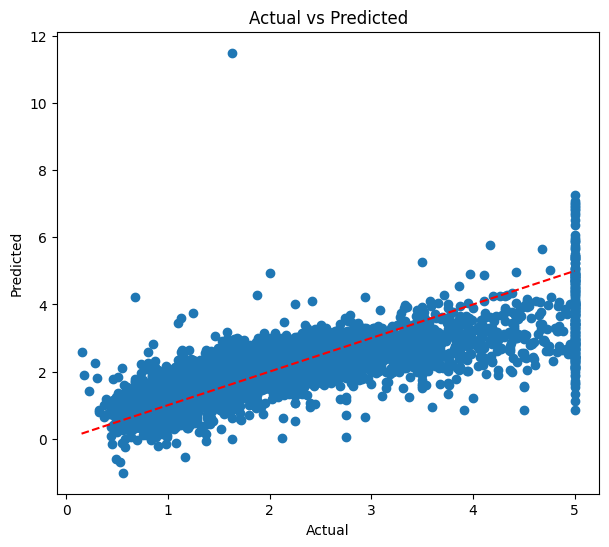

In [6]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, pred_lr)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

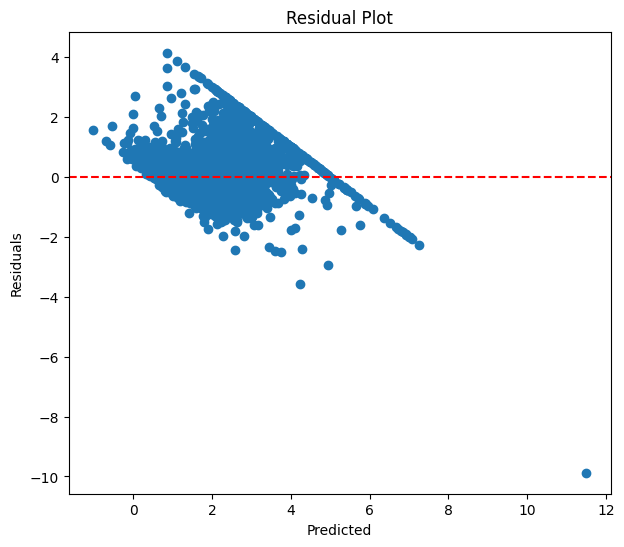

In [7]:
residuals = y_test - pred_lr

plt.figure(figsize=(7,6))

plt.scatter(pred_lr, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [8]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

In [9]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

In [10]:
results = pd.DataFrame(columns=[
    "Model",
    "MSE",
    "RMSE",
    "MAE",
    "R2"
])

models = {
    "Linear Regression": pred_lr,
    "Ridge": pred_ridge,
    "Lasso": pred_lasso
}

for name, pred in models.items():

    mse = mean_squared_error(y_test, pred)

    results.loc[len(results)] = [
        name,
        mse,
        np.sqrt(mse),
        mean_absolute_error(y_test, pred),
        r2_score(y_test, pred)
    ]

print(results)

               Model       MSE      RMSE       MAE        R2
0  Linear Regression  0.555892  0.745581  0.533200  0.575788
1              Ridge  0.555803  0.745522  0.533204  0.575855
2              Lasso  0.544449  0.737868  0.536250  0.584520


In [11]:
mlflow.set_experiment("Linear_Regression_Comparison")

with mlflow.start_run():

    mlflow.log_param("dataset", "California Housing")
    mlflow.log_param("models", "Linear,Ridge,Lasso")

    best = results.sort_values("R2", ascending=False).iloc[0]

    mlflow.log_metric("Best_R2", best["R2"])
    mlflow.log_metric("Best_RMSE", best["RMSE"])

    mlflow.sklearn.log_model(lr, "LinearRegression")

print("MLflow logging completed.")

2026/08/05 16:12:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/05 16:12:27 INFO mlflow.store.db.utils: Updating database tables
2026/08/05 16:12:32 INFO mlflow.tracking.fluent: Experiment with name 'Linear_Regression_Comparison' does not exist. Creating a new experiment.
2026/08/05 16:12:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow logging completed.
